In [1]:
#import the dataset
from google.colab import files
uploads=files.upload()

Saving Train.csv to Train.csv
Saving Test.csv to Test.csv


In [2]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from transformers import AutoTokenizer,AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

First few rows of the dataset
         ID                                               text       label
0  SUAVK39Z            I feel that it was better I dieAm happy  Depression
1  9JDAGUV3                       Why do I get hallucinations?       Drugs
2  419WR1LQ  I am stresseed due to lack of financial suppor...  Depression
3  6UY7DX6Q                             Why is life important?     Suicide
4  FYC0FTFB  How could I be helped to go through the depres...  Depression

Distribution: (616, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      616 non-null    object
 1   text    616 non-null    object
 2   label   616 non-null    object
dtypes: object(3)
memory usage: 14.6+ KB
None

Missing values:
ID       0
text     0
label    0
dtype: int64

Duplicates:
0

New dataframe
                                                text       label
0       

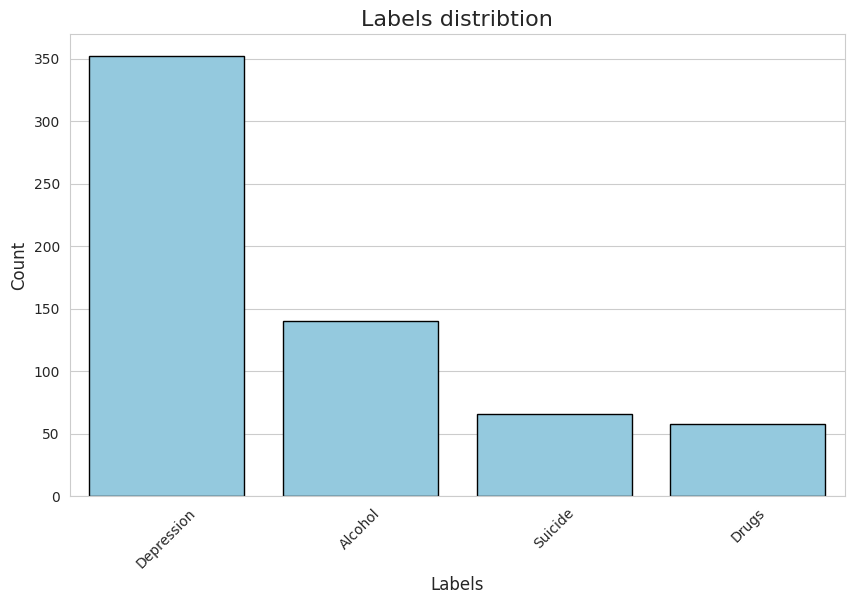

In [3]:
#inspect the dataset
train=pd.read_csv('Train.csv')
test=pd.read_csv("Test.csv")
print("First few rows of the dataset")
print(train.head())

#shape
print(f"\nDistribution: {train.shape}")

print(train.info())

#check for missing values
print("\nMissing values:")
print(train.isnull().sum())

#check for duplicates
print("\nDuplicates:")
print(train.duplicated().sum())

#drop the id column
train=train.drop(columns=['ID'])
print("\nNew dataframe")
print(train.head())

#inspect label count
label_counts=train['label'].value_counts()
print(f"\n{label_counts}")
#plot results
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.barplot(x=label_counts.index,y=label_counts.values,color='skyblue',edgecolor='black')
plt.title('Labels distribtion',fontsize=16)
plt.xlabel('Labels',fontsize=12)
plt.ylabel('Count',fontsize=12)
plt.xticks(rotation=45)
plt.show()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

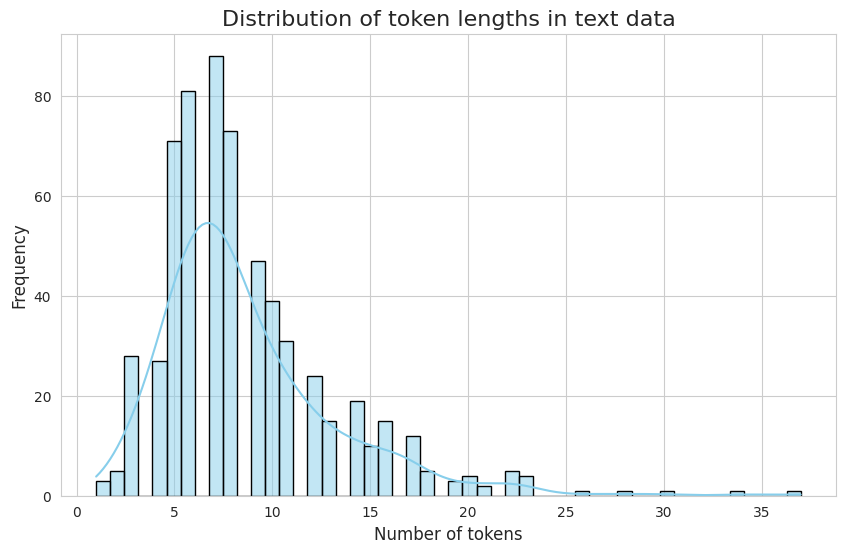

In [4]:
#check for token length in text
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
train['token_len'] = train['text'].apply(lambda x: len(tokenizer.tokenize(str(x))))
train['token_len'].describe()

#plot the results
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(data=train,x='token_len',bins=50,kde=True,color='skyblue',edgecolor='black')
plt.title("Distribution of token lengths in text data",fontsize=16)
plt.xlabel("Number of tokens",fontsize=12)
plt.ylabel("Frequency",fontsize=12)
plt.show()

In [5]:
#embedding extraction
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 30

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def get_embeddings(texts, batch_size=16):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**encoded)

        # Mean pooling over tokens (masking out padding)
        token_embeddings = outputs.last_hidden_state
        attention_mask = encoded['attention_mask'].unsqueeze(-1)
        masked_embeddings = token_embeddings * attention_mask
        summed = masked_embeddings.sum(dim=1)
        counts = attention_mask.sum(dim=1)
        mean_pooled = summed / counts

        all_embeddings.append(mean_pooled.cpu().numpy())

    return np.vstack(all_embeddings)

X_train = get_embeddings(train['text'].tolist())
X_test = get_embeddings(test['text'].tolist())
y_train = train['label']

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
#train the model
clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

y_proba = clf.predict_proba(X_test)

#view results
test_df = test.copy()

# build probability dataframe using clf.classes_ to get correct label-column mapping
proba_df = pd.DataFrame(y_proba, columns=clf.classes_)

final_df = pd.concat([test_df[['ID']].reset_index(drop=True), proba_df.reset_index(drop=True)], axis=1)

desired_order = ['ID', 'Depression', 'Alcohol', 'Suicide', 'Drugs']

for col in desired_order:
    if col not in final_df.columns:
        final_df[col] = 0.0

final_df = final_df[desired_order]
print(final_df.head(5))
final_df.to_csv('predictions.csv', index=False)
print("CSV saved successfully!")

         ID  Depression   Alcohol   Suicide     Drugs
0  02V56KMO    0.808043  0.005051  0.186867  0.000039
1  03BMGTOK    0.990928  0.000438  0.008544  0.000089
2  03LZVFM6    0.980094  0.000012  0.019877  0.000017
3  0EPULUM5    0.821794  0.000616  0.175562  0.002028
4  0GM4C5GD    0.041301  0.055705  0.002207  0.900786
CSV saved successfully!
